# Improved Baseline Suite for Financial Time-Series Forecasting

**CIS 7000 — Robust Financial Time-Series Forecasting under Domain Shift**

---

## Motivation

Our previous baseline notebook trained CNN, RNN, LSTM, GRU, and Transformer models on raw OHLCV prices and found that **every model simply learned to copy yesterday's price**. The naive baseline (predict yesterday's close) beat all trained models, and directional accuracy was ~50% — a coin flip.

This happened because:
1. **Raw prices are highly autocorrelated.** Today's price ≈ yesterday's price, so MSE-minimizing models converge to the identity.
2. **We had no classical/statistical baselines** to properly benchmark against.
3. **We used no engineered features** — raw OHLCV alone carries almost no predictive signal for *changes*.
4. **We only evaluated one task** (price prediction) despite our proposal targeting multiple tasks.

This notebook fixes all of that. We build a comprehensive, honest baseline suite that:

- **Predicts log-returns** instead of raw prices (removes non-stationarity)
- **Adds technical indicators** as engineered features (RSI, MACD, Bollinger Bands, ATR, OBV)
- **Includes classical statistical baselines**: ARIMA, Linear Regression, Ridge with technical indicators
- **Includes a GARCH baseline** for volatility forecasting (aligned with our multi-task proposal)
- **Includes direction classification baselines**: Logistic Regression, Random Forest
- **Re-runs deep learning models** on the improved feature set
- **Applies proper statistical tests**: Diebold-Mariano test, binomial test for directional accuracy
- **Preserves the same evaluation protocol**: train pre-2024, val/test post-2024, Tesla as holdout

The goal is to establish **credible baselines that our sentiment-enhanced and multi-task models must beat.**

---

### Notebook Structure

| Section | What it does |
|---|---|
| §1 | Setup & Installation |
| §2 | Configuration |
| §3 | Data Loading & Alignment |
| §4 | Feature Engineering (returns, technical indicators) |
| §5 | Data Preprocessing & Dataset Creation |
| §6 | Naive & Statistical Baselines (Naive, Historical Mean, EMA, ARIMA, Linear, Ridge) |
| §7 | Deep Learning Models (LSTM, GRU, Transformer) on improved features |
| §8 | Direction Classification Baselines |
| §9 | Volatility Forecasting — GARCH Baseline |
| §10 | Statistical Significance Tests |
| §11 | Final Comparison Dashboard |

**Runtime**: `Runtime > Change runtime type > T4 GPU`

---
## §1. Setup & Installation

In [ ]:
!pip install -q torch torchvision numpy pandas scikit-learn matplotlib statsmodels arch scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 15.4 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report
from statsmodels.tsa.arima.model import ARIMA
from arch import arch_model
from scipy import stats
import warnings
import math
import os

warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

Using device: cuda


---
## §2. Configuration

Same evaluation protocol as the original notebook: train on pre-2024, validate/test on post-2024, Tesla as the unseen holdout stock. The key change is that we now predict **log-returns** and use **technical indicators** as features.

In [ ]:
# ============================================================
# CONFIGURATION — edit these to match your setup
# ============================================================

HOLDOUT_STOCK = 'TSLA'           # Held out entirely for testing
TRAIN_CUTOFF = '2024-01-01'      # Train on data before this date

# Sequence / model hyperparameters
SEQUENCE_LENGTH = 60             # 60 trading days (~3 months) lookback
FORECAST_HORIZON = 1             # Predict 1 day ahead
BATCH_SIZE = 64
EPOCHS = 50
LEARNING_RATE = 0.001

print(f"Holdout stock: {HOLDOUT_STOCK}")
print(f"Train cutoff:  {TRAIN_CUTOFF}")
print(f"Lookback:      {SEQUENCE_LENGTH} days")

Holdout stock: TSLA
Train cutoff:  2024-01-01
Lookback:      60 days


---
## §3. Data Loading & Alignment

Load historical OHLCV data from Google Drive (same CSVs as original notebook), then align all stocks to the latest common start date.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# UPDATE THIS to your actual Google Drive folder path
DRIVE_FOLDER = "/content/drive/MyDrive/DL4TS-Term-Project/"

FILE_NAMES = {
    'AAPL': 'Historical_Data_AAPL.csv',
    'GOOG': 'Historical_Data_GOOG.csv',
    'META': 'Historical_Data_META.csv',
    'NVDA': 'Historical_Data_NVDA.csv',
    'TSLA': 'Historical_Data_TSLA.csv',
}

Mounted at /content/drive


In [ ]:
def load_stock_data(folder, file_names):
    """Load all stock CSVs from Google Drive."""
    stocks = {}
    for ticker, fname in file_names.items():
        path = folder + fname
        print(f"Loading {ticker} from {path}...")
        df = pd.read_csv(path)
        df['Date'] = pd.to_datetime(df['Date'], utc=True)
        df['Date'] = df['Date'].dt.tz_localize(None)
        df = df.sort_values('Date').reset_index(drop=True)
        stocks[ticker] = df
        print(f"  {ticker}: {len(df)} rows, {df['Date'].min().date()} to {df['Date'].max().date()}")
    return stocks


def align_stocks(stocks_dict):
    """
    Align all stocks to the latest common start date.
    e.g., if AAPL starts 1982 but META starts 2012, everyone starts from 2012.
    """
    start_dates = {t: df['Date'].min() for t, df in stocks_dict.items()}
    common_start = max(start_dates.values())

    print(f"\nIndividual start dates:")
    for t, d in sorted(start_dates.items(), key=lambda x: x[1]):
        print(f"  {t}: {d.date()}")
    print(f"\nCommon start date (latest): {common_start.date()}")

    aligned = {}
    for ticker, df in stocks_dict.items():
        trimmed = df[df['Date'] >= common_start].copy().reset_index(drop=True)
        aligned[ticker] = trimmed
        print(f"  {ticker}: {len(trimmed)} rows after alignment")

    return aligned, common_start


raw_stocks = load_stock_data(DRIVE_FOLDER, FILE_NAMES)
stocks, common_start = align_stocks(raw_stocks)

Loading AAPL from /content/drive/MyDrive/DL4TS-Term-Project/Historical_Data_AAPL.csv...
  AAPL: 11383 rows, 1980-12-12 to 2026-02-11
Loading GOOG from /content/drive/MyDrive/DL4TS-Term-Project/Historical_Data_GOOG.csv...
  GOOG: 5405 rows, 2004-08-19 to 2026-02-11
Loading META from /content/drive/MyDrive/DL4TS-Term-Project/Historical_Data_META.csv...
  META: 3453 rows, 2012-05-18 to 2026-02-11
Loading NVDA from /content/drive/MyDrive/DL4TS-Term-Project/Historical_Data_NVDA.csv...
  NVDA: 6806 rows, 1999-01-22 to 2026-02-11
Loading TSLA from /content/drive/MyDrive/DL4TS-Term-Project/Historical_Data_TSLA.csv...
  TSLA: 3930 rows, 2010-06-29 to 2026-02-11

Individual start dates:
  AAPL: 1980-12-12
  NVDA: 1999-01-22
  GOOG: 2004-08-19
  TSLA: 2010-06-29
  META: 2012-05-18

Common start date (latest): 2012-05-18
  AAPL: 3453 rows after alignment
  GOOG: 3453 rows after alignment
  META: 3453 rows after alignment
  NVDA: 3453 rows after alignment
  TSLA: 3453 rows after alignment


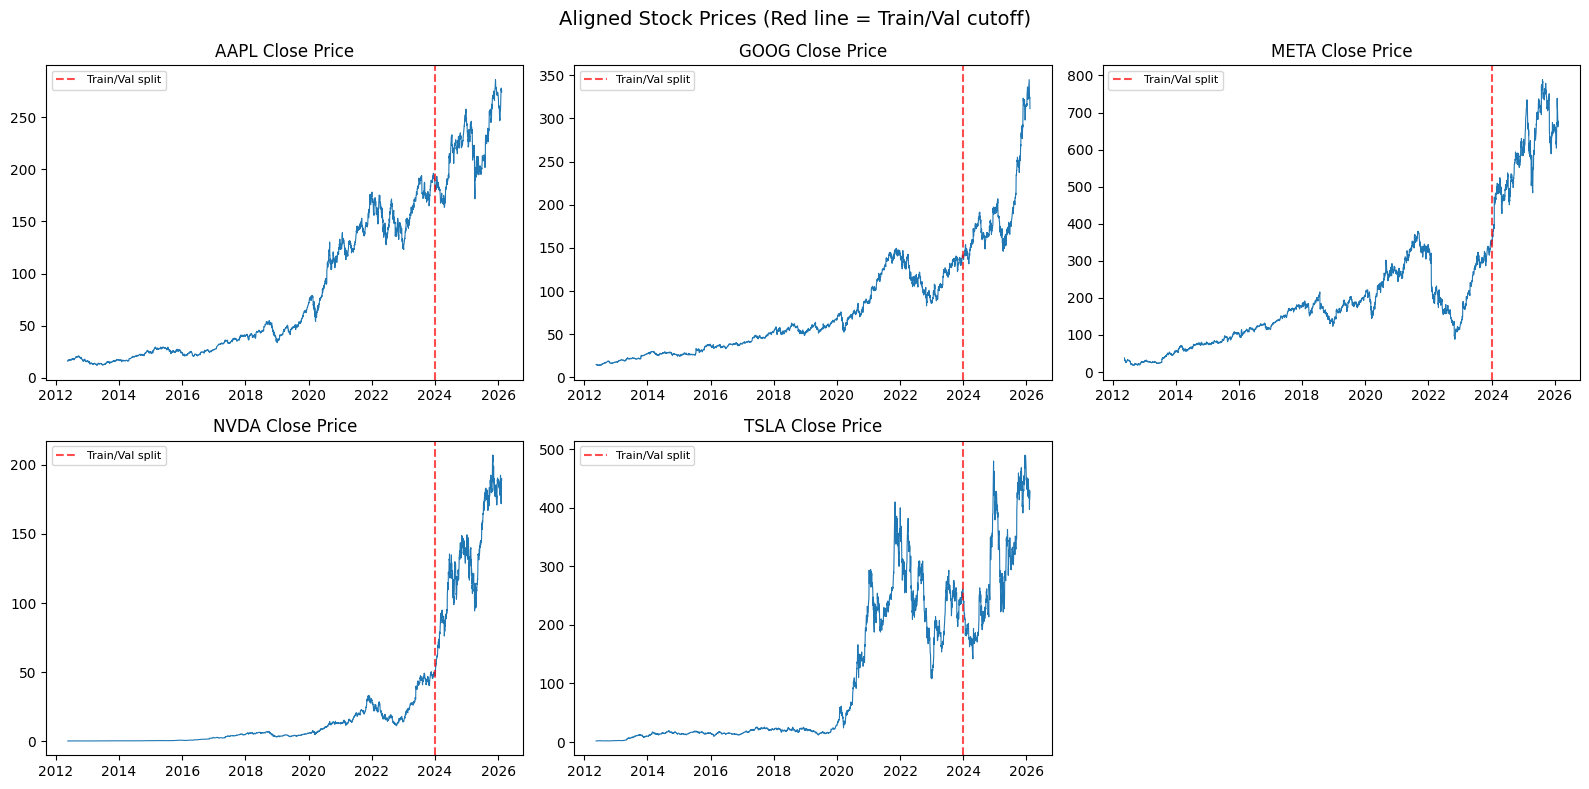

In [ ]:
# Quick visualization
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, (ticker, df) in enumerate(stocks.items()):
    axes[i].plot(df['Date'], df['Close'], linewidth=0.8)
    axes[i].set_title(f'{ticker} Close Price')
    axes[i].axvline(x=pd.Timestamp(TRAIN_CUTOFF), color='r', linestyle='--', alpha=0.7, label='Train/Val split')
    axes[i].legend(fontsize=8)
for j in range(len(stocks), len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Aligned Stock Prices (Red line = Train/Val cutoff)', fontsize=14)
plt.tight_layout()
plt.show()

---
## §4. Feature Engineering

This is the **key improvement** over the original notebook. Instead of feeding raw OHLCV prices, we:

1. **Compute log-returns** as the prediction target. Log-returns are approximately stationary and additive, which removes the non-stationarity that caused our models to learn the identity function.

2. **Add technical indicators** that the trading community uses as predictive features:
   - **RSI (Relative Strength Index)**: Momentum oscillator, 0–100. Values > 70 suggest overbought, < 30 oversold.
   - **MACD**: Difference between 12-day and 26-day EMAs. Signal line crossovers indicate momentum shifts.
   - **Bollinger Band Width**: Measures volatility as the spread between upper and lower bands.
   - **ATR (Average True Range)**: Volatility indicator based on the range of daily price movement.
   - **OBV (On-Balance Volume)**: Cumulative volume indicator that relates volume flow to price changes.
   - **Volume Change (%)**: Rate of change in volume.
   - **Lagged returns**: Past 1, 2, 3, 5 day returns as autoregressive features.

Why these? They capture momentum, volatility, and volume dynamics — the three dimensions most commonly used in quantitative finance. Later, our sentiment features will be added as a fourth dimension.

In [ ]:
def compute_rsi(series, window=14):
    """Relative Strength Index."""
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.rolling(window=window, min_periods=window).mean()
    avg_loss = loss.rolling(window=window, min_periods=window).mean()
    rs = avg_gain / (avg_loss + 1e-10)
    return 100 - (100 / (1 + rs))


def compute_macd(series, fast=12, slow=26, signal=9):
    """MACD line, signal line, and histogram."""
    ema_fast = series.ewm(span=fast, adjust=False).mean()
    ema_slow = series.ewm(span=slow, adjust=False).mean()
    macd_line = ema_fast - ema_slow
    signal_line = macd_line.ewm(span=signal, adjust=False).mean()
    histogram = macd_line - signal_line
    return macd_line, signal_line, histogram


def compute_bollinger_bands(series, window=20, num_std=2):
    """Bollinger Band width (normalized by middle band)."""
    sma = series.rolling(window=window).mean()
    std = series.rolling(window=window).std()
    upper = sma + num_std * std
    lower = sma - num_std * std
    bandwidth = (upper - lower) / (sma + 1e-10)
    # Also compute %B: where is price relative to the bands?
    pct_b = (series - lower) / (upper - lower + 1e-10)
    return bandwidth, pct_b


def compute_atr(high, low, close, window=14):
    """Average True Range."""
    tr1 = high - low
    tr2 = (high - close.shift(1)).abs()
    tr3 = (low - close.shift(1)).abs()
    true_range = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)
    return true_range.rolling(window=window).mean()


def compute_obv(close, volume):
    """On-Balance Volume (normalized as rate of change)."""
    direction = np.sign(close.diff())
    obv = (volume * direction).cumsum()
    # Normalize: use rate of change of OBV rather than raw cumulative sum
    obv_roc = obv.pct_change(periods=5)
    return obv_roc


def add_features(df):
    df = df.copy()

    # --- Target: log-return ---
    df['log_return'] = np.log(df['Close'] / df['Close'].shift(1))

    # --- Lagged returns (autoregressive features) ---
    for lag in [1, 2, 3, 5]:
        df[f'return_lag_{lag}'] = df['log_return'].shift(lag)

    # --- OHLCV features (shifted to avoid leakage) ---
    df['high_low_range'] = ((df['High'] - df['Low']) / df['Close']).shift(1)
    df['open_close_diff'] = ((df['Close'] - df['Open']) / df['Open']).shift(1)
    df['volume_change'] = df['Volume'].pct_change().shift(1)
    df['volume_ma_ratio'] = (df['Volume'] / df['Volume'].rolling(20).mean()).shift(1)

    # --- Technical indicators (all shift(1) since they use today's close) ---
    df['rsi'] = compute_rsi(df['Close']).shift(1)

    macd_line, macd_signal, macd_hist = compute_macd(df['Close'])
    df['macd'] = (macd_line / df['Close']).shift(1)
    df['macd_signal'] = (macd_signal / df['Close']).shift(1)
    df['macd_hist'] = (macd_hist / df['Close']).shift(1)

    bandwidth, pct_b = compute_bollinger_bands(df['Close'])
    df['bb_width'] = bandwidth.shift(1)
    df['bb_pct_b'] = pct_b.shift(1)

    df['atr'] = (compute_atr(df['High'], df['Low'], df['Close']) / df['Close']).shift(1)

    df['obv_roc'] = compute_obv(df['Close'], df['Volume']).shift(1)

    # --- Volatility features (shifted — they include today's return) ---
    df['realized_vol_5d'] = (df['log_return'].rolling(5).std() * np.sqrt(252)).shift(1)
    df['realized_vol_20d'] = (df['log_return'].rolling(20).std() * np.sqrt(252)).shift(1)

    # --- Direction label ---
    df['direction'] = (df['log_return'] > 0).astype(int)

    df = df.dropna().reset_index(drop=True)
    return df

# Apply feature engineering to all stocks
stocks_featured = {}
for ticker, df in stocks.items():
    stocks_featured[ticker] = add_features(df)
    print(f"{ticker}: {len(stocks_featured[ticker])} rows after feature engineering")

# List of feature columns (everything except Date, raw OHLCV, and targets)
FEATURE_COLS = [
    'return_lag_1', 'return_lag_2', 'return_lag_3', 'return_lag_5',
    'high_low_range', 'open_close_diff', 'volume_change', 'volume_ma_ratio',
    'rsi', 'macd', 'macd_signal', 'macd_hist',
    'bb_width', 'bb_pct_b', 'atr', 'obv_roc',
    'realized_vol_5d', 'realized_vol_20d'
]

TARGET_COL = 'log_return'
DIRECTION_COL = 'direction'
VOLATILITY_COL = 'realized_vol_20d'

print(f"\nFeature columns ({len(FEATURE_COLS)}): {FEATURE_COLS}")
print(f"Target: {TARGET_COL}")

AAPL: 3432 rows after feature engineering
GOOG: 3432 rows after feature engineering
META: 3432 rows after feature engineering
NVDA: 3432 rows after feature engineering
TSLA: 3432 rows after feature engineering

Feature columns (18): ['return_lag_1', 'return_lag_2', 'return_lag_3', 'return_lag_5', 'high_low_range', 'open_close_diff', 'volume_change', 'volume_ma_ratio', 'rsi', 'macd', 'macd_signal', 'macd_hist', 'bb_width', 'bb_pct_b', 'atr', 'obv_roc', 'realized_vol_5d', 'realized_vol_20d']
Target: log_return


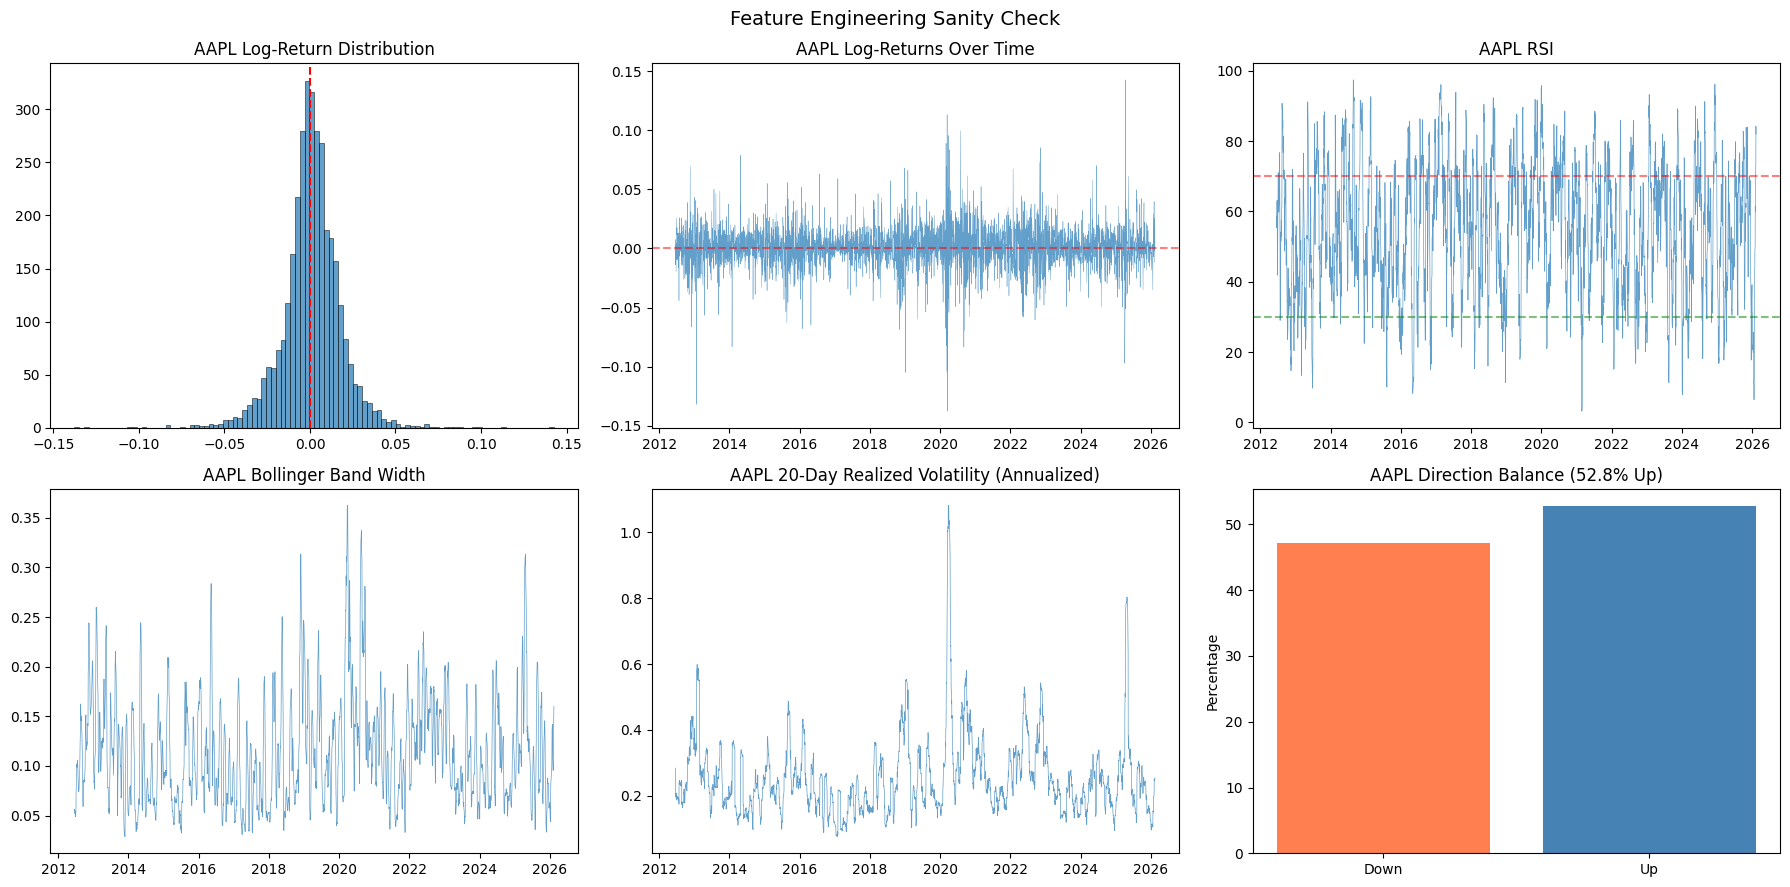


Return stats for AAPL:
count    3432.000000
mean        0.000802
std         0.017830
min        -0.137708
25%        -0.007421
50%         0.000898
75%         0.009987
max         0.142617
Name: log_return, dtype: float64


In [ ]:
# Visualize the return distribution and some key features for one stock
sample_ticker = 'AAPL'
sample_df = stocks_featured[sample_ticker]

fig, axes = plt.subplots(2, 3, figsize=(18, 9))

# Log returns distribution
axes[0, 0].hist(sample_df['log_return'], bins=100, alpha=0.7, edgecolor='black', linewidth=0.5)
axes[0, 0].set_title(f'{sample_ticker} Log-Return Distribution')
axes[0, 0].axvline(0, color='r', linestyle='--')

# Log returns over time
axes[0, 1].plot(sample_df['Date'], sample_df['log_return'], linewidth=0.3, alpha=0.7)
axes[0, 1].set_title(f'{sample_ticker} Log-Returns Over Time')
axes[0, 1].axhline(0, color='r', linestyle='--', alpha=0.5)

# RSI
axes[0, 2].plot(sample_df['Date'], sample_df['rsi'], linewidth=0.5, alpha=0.7)
axes[0, 2].axhline(70, color='r', linestyle='--', alpha=0.5)
axes[0, 2].axhline(30, color='g', linestyle='--', alpha=0.5)
axes[0, 2].set_title(f'{sample_ticker} RSI')

# Bollinger Band width
axes[1, 0].plot(sample_df['Date'], sample_df['bb_width'], linewidth=0.5, alpha=0.7)
axes[1, 0].set_title(f'{sample_ticker} Bollinger Band Width')

# Realized volatility
axes[1, 1].plot(sample_df['Date'], sample_df['realized_vol_20d'], linewidth=0.5, alpha=0.7)
axes[1, 1].set_title(f'{sample_ticker} 20-Day Realized Volatility (Annualized)')

# Direction balance
up_pct = sample_df['direction'].mean() * 100
axes[1, 2].bar(['Down', 'Up'], [100 - up_pct, up_pct], color=['coral', 'steelblue'])
axes[1, 2].set_title(f'{sample_ticker} Direction Balance ({up_pct:.1f}% Up)')
axes[1, 2].set_ylabel('Percentage')

plt.suptitle('Feature Engineering Sanity Check', fontsize=14)
plt.tight_layout()
plt.show()

print(f"\nReturn stats for {sample_ticker}:")
print(sample_df['log_return'].describe())

---
## §5. Data Preprocessing & Dataset Creation

We split each stock into train (pre-2024) and val/test (post-2024), using **StandardScaler** instead of MinMaxScaler (better for return-based features that can be negative). Tesla is held out entirely for testing.

We also prepare flat arrays for the classical baselines (which don't need windowed sequences) alongside the PyTorch datasets for deep learning models.

In [ ]:
# ==============================================================
# 5a. Prepare FLAT data for classical baselines
# ==============================================================
# Classical models (Linear Regression, Ridge, ARIMA, etc.) don't
# need sliding-window sequences. They operate on flat feature vectors.
# ==============================================================

cutoff_date = pd.Timestamp(TRAIN_CUTOFF)

def split_stock(df, cutoff):
    """Split a single stock into train and test portions."""
    train = df[df['Date'] < cutoff].copy()
    test = df[df['Date'] >= cutoff].copy()
    return train, test

# Store split data for each stock
stock_splits = {}
for ticker, df in stocks_featured.items():
    train_df, test_df = split_stock(df, cutoff_date)
    stock_splits[ticker] = {'train': train_df, 'test': test_df}
    print(f"{ticker}: {len(train_df)} train, {len(test_df)} test")


# For classical baselines: pool all training stocks (except holdout)
train_stocks = [t for t in stocks_featured if t != HOLDOUT_STOCK]
print(f"\nTraining stocks: {train_stocks}")
print(f"Holdout stock:   {HOLDOUT_STOCK}")

# Pool training data
classical_train_X = pd.concat([stock_splits[t]['train'][FEATURE_COLS] for t in train_stocks])
classical_train_y_return = pd.concat([stock_splits[t]['train'][TARGET_COL] for t in train_stocks])
classical_train_y_dir = pd.concat([stock_splits[t]['train'][DIRECTION_COL] for t in train_stocks])

# Validation: same training stocks, post-cutoff
classical_val_X = pd.concat([stock_splits[t]['test'][FEATURE_COLS] for t in train_stocks])
classical_val_y_return = pd.concat([stock_splits[t]['test'][TARGET_COL] for t in train_stocks])
classical_val_y_dir = pd.concat([stock_splits[t]['test'][DIRECTION_COL] for t in train_stocks])

# Test: holdout stock, post-cutoff
classical_test_X = stock_splits[HOLDOUT_STOCK]['test'][FEATURE_COLS]
classical_test_y_return = stock_splits[HOLDOUT_STOCK]['test'][TARGET_COL]
classical_test_y_dir = stock_splits[HOLDOUT_STOCK]['test'][DIRECTION_COL]

# Scale features (fit on training only)
classical_scaler = StandardScaler()
classical_train_X_scaled = classical_scaler.fit_transform(classical_train_X)
classical_val_X_scaled = classical_scaler.transform(classical_val_X)
classical_test_X_scaled = classical_scaler.transform(classical_test_X)

print(f"\nClassical data shapes:")
print(f"  Train: X={classical_train_X_scaled.shape}, y={classical_train_y_return.shape}")
print(f"  Val:   X={classical_val_X_scaled.shape}, y={classical_val_y_return.shape}")
print(f"  Test:  X={classical_test_X_scaled.shape}, y={classical_test_y_return.shape}")

AAPL: 2902 train, 530 test
GOOG: 2902 train, 530 test
META: 2902 train, 530 test
NVDA: 2902 train, 530 test
TSLA: 2902 train, 530 test

Training stocks: ['AAPL', 'GOOG', 'META', 'NVDA']
Holdout stock:   TSLA

Classical data shapes:
  Train: X=(11608, 18), y=(11608,)
  Val:   X=(2120, 18), y=(2120,)
  Test:  X=(530, 18), y=(530,)


In [ ]:
# ==============================================================
# 5b. Prepare WINDOWED data for deep learning models
# ==============================================================
# Deep learning models (LSTM, GRU, Transformer) need sliding-window
# sequences of shape (batch, sequence_length, num_features).
# ==============================================================

class StockDataset(Dataset):
    """PyTorch Dataset for windowed stock sequences."""
    def __init__(self, features, targets, seq_len):
        self.features = torch.FloatTensor(features)
        self.targets = torch.FloatTensor(targets)
        self.seq_len = seq_len

    def __len__(self):
        return len(self.features) - self.seq_len

    def __getitem__(self, idx):
        x = self.features[idx:idx + self.seq_len]
        y = self.targets[idx + self.seq_len]
        return x, y


def prepare_dl_data(stocks_featured, holdout_ticker, feature_cols, target_col, train_cutoff, seq_len):
    """
    Prepare windowed datasets for deep learning.
    Each stock is scaled independently (fit on train portion only).
    """
    train_feats, train_tgts = [], []
    val_feats, val_tgts = [], []
    test_feats, test_tgts = [], []
    scalers = {}

    cutoff = pd.Timestamp(train_cutoff)

    for ticker, df in stocks_featured.items():
        train_mask = df['Date'] < cutoff
        val_mask = df['Date'] >= cutoff

        train_f = df[train_mask][feature_cols].values
        train_t = df[train_mask][target_col].values
        val_f = df[val_mask][feature_cols].values
        val_t = df[val_mask][target_col].values

        # Fit StandardScaler on training data
        scaler = StandardScaler()
        train_scaled = scaler.fit_transform(train_f)
        val_scaled = scaler.transform(val_f)
        scalers[ticker] = scaler

        if ticker == holdout_ticker:
            # Use end of training as lead-in for sequence context
            combined_f = np.concatenate([train_scaled[-seq_len:], val_scaled], axis=0)
            combined_t = np.concatenate([train_t[-seq_len:], val_t], axis=0)
            test_feats.append(combined_f)
            test_tgts.append(combined_t)
            print(f"  {ticker} [TEST]:  {len(val_f)} points (+ {seq_len} lead-in)")
        else:
            train_feats.append(train_scaled)
            train_tgts.append(train_t)

            combined_val_f = np.concatenate([train_scaled[-seq_len:], val_scaled], axis=0)
            combined_val_t = np.concatenate([train_t[-seq_len:], val_t], axis=0)
            val_feats.append(combined_val_f)
            val_tgts.append(combined_val_t)
            print(f"  {ticker} [TRAIN]: {len(train_f)} train, {len(val_f)} val")

    # Build PyTorch datasets
    train_dataset = torch.utils.data.ConcatDataset(
        [StockDataset(f, t, seq_len) for f, t in zip(train_feats, train_tgts)]
    )
    val_dataset = torch.utils.data.ConcatDataset(
        [StockDataset(f, t, seq_len) for f, t in zip(val_feats, val_tgts)]
    )
    test_dataset = torch.utils.data.ConcatDataset(
        [StockDataset(f, t, seq_len) for f, t in zip(test_feats, test_tgts)]
    )

    print(f"\nDataset sizes: Train={len(train_dataset)}, Val={len(val_dataset)}, Test={len(test_dataset)}")
    return train_dataset, val_dataset, test_dataset, scalers


print("Preparing windowed data for deep learning...\n")
train_dataset, val_dataset, test_dataset, dl_scalers = prepare_dl_data(
    stocks_featured, HOLDOUT_STOCK, FEATURE_COLS, TARGET_COL, TRAIN_CUTOFF, SEQUENCE_LENGTH
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

NUM_FEATURES = len(FEATURE_COLS)
print(f"\nInput shape per sample: ({SEQUENCE_LENGTH}, {NUM_FEATURES})")

Preparing windowed data for deep learning...

  AAPL [TRAIN]: 2902 train, 530 val
  GOOG [TRAIN]: 2902 train, 530 val
  META [TRAIN]: 2902 train, 530 val
  NVDA [TRAIN]: 2902 train, 530 val
  TSLA [TEST]:  530 points (+ 60 lead-in)

Dataset sizes: Train=11368, Val=2120, Test=530

Input shape per sample: (60, 18)


---
## §6. Naive & Statistical Baselines

These are the baselines that our original notebook was missing entirely. In financial forecasting, you must beat these before claiming your deep learning model "works":

| Baseline | What it predicts | Why it matters |
|---|---|---|
| **Naive (Zero Return)** | Tomorrow's return = 0 | In return-space, this is equivalent to "tomorrow's price = today's price". This is the bar to beat. |
| **Historical Mean** | Tomorrow's return = average historical return | Tests whether unconditional mean has value. |
| **EMA** | Exponentially weighted moving average of recent returns | A popular practitioner heuristic. |
| **Linear Regression** | OLS on technical indicator features | Tests whether there's any linear predictive structure. |
| **Ridge Regression** | L2-regularized linear model on same features | Tests robustness to overfitting. |
| **ARIMA** | Autoregressive model on the return series | The standard statistical time-series baseline. |

In [ ]:
# ==============================================================
# Evaluation Utilities
# ==============================================================

def regression_metrics(y_true, y_pred, label=''):
    """Compute standard regression metrics for return prediction."""
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mse = np.mean((y_true - y_pred) ** 2)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(y_true - y_pred))

    # Directional accuracy: did we predict the sign correctly?
    actual_dir = (y_true > 0).astype(int)
    pred_dir = (y_pred > 0).astype(int)
    dir_acc = np.mean(actual_dir == pred_dir) * 100

    # Correlation
    if np.std(y_pred) > 1e-10:
        corr = np.corrcoef(y_true, y_pred)[0, 1]
    else:
        corr = 0.0

    metrics = {'mse': mse, 'rmse': rmse, 'mae': mae, 'dir_acc': dir_acc, 'corr': corr}

    if label:
        print(f"  {label} | RMSE: {rmse:.6f} | MAE: {mae:.6f} | Dir Acc: {dir_acc:.1f}% | Corr: {corr:.4f}")

    return metrics


# Store all results for final comparison
ALL_RESULTS = {}  # model_name -> {'val': metrics, 'test': metrics, 'test_preds': array}

In [ ]:
# ==============================================================
# 6a. Naive Baseline (predict zero return)
# ==============================================================
# In return-space, the naive baseline is: r_hat = 0.
# This is equivalent to saying "price won't change" = yesterday's close.
# ==============================================================

print("=" * 60)
print("NAIVE BASELINE (predict zero return)")
print("=" * 60)

naive_val_preds = np.zeros(len(classical_val_y_return))
naive_test_preds = np.zeros(len(classical_test_y_return))

print("Validation:")
naive_val_metrics = regression_metrics(classical_val_y_return, naive_val_preds, 'Naive')
print("Test (TSLA):")
naive_test_metrics = regression_metrics(classical_test_y_return, naive_test_preds, 'Naive')

ALL_RESULTS['Naive (r=0)'] = {
    'val': naive_val_metrics, 'test': naive_test_metrics,
    'test_preds': naive_test_preds
}

NAIVE BASELINE (predict zero return)
Validation:
  Naive | RMSE: 0.023448 | MAE: 0.015869 | Dir Acc: 45.7% | Corr: 0.0000
Test (TSLA):
  Naive | RMSE: 0.038880 | MAE: 0.028290 | Dir Acc: 49.8% | Corr: 0.0000


In [ ]:
# ==============================================================
# 6b. Historical Mean Baseline
# ==============================================================
# Predict the average daily return from training data.
# This tests whether the unconditional mean return has any value.
# ==============================================================

print("=" * 60)
print("HISTORICAL MEAN BASELINE")
print("=" * 60)

hist_mean = classical_train_y_return.mean()
print(f"Historical mean daily return: {hist_mean:.6f} ({hist_mean*252*100:.2f}% annualized)")

histmean_val_preds = np.full(len(classical_val_y_return), hist_mean)
histmean_test_preds = np.full(len(classical_test_y_return), hist_mean)

print("Validation:")
histmean_val_metrics = regression_metrics(classical_val_y_return, histmean_val_preds, 'HistMean')
print("Test (TSLA):")
histmean_test_metrics = regression_metrics(classical_test_y_return, histmean_test_preds, 'HistMean')

ALL_RESULTS['Hist. Mean'] = {
    'val': histmean_val_metrics, 'test': histmean_test_metrics,
    'test_preds': histmean_test_preds
}

HISTORICAL MEAN BASELINE
Historical mean daily return: 0.001056 (26.62% annualized)
Validation:
  HistMean | RMSE: 0.023404 | MAE: 0.015803 | Dir Acc: 54.3% | Corr: 0.0000
Test (TSLA):
  HistMean | RMSE: 0.038867 | MAE: 0.028298 | Dir Acc: 50.2% | Corr: 0.0000


In [ ]:
# ==============================================================
# 6c. Exponential Moving Average (EMA) Baseline
# ==============================================================
# Predict tomorrow's return as the EMA of recent returns.
# This is a popular practitioner heuristic that gives more weight
# to recent observations.
# ==============================================================

print("=" * 60)
print("EMA BASELINE (span=10)")
print("=" * 60)

# For the holdout stock, compute EMA of returns on the test period
# using data available up to each point (no look-ahead)
holdout_full = stocks_featured[HOLDOUT_STOCK].copy()
holdout_test_mask = holdout_full['Date'] >= cutoff_date

# Compute EMA on full series, then extract test portion
# The EMA at time t uses only data up to t-1 (shift by 1)
ema_preds_full = holdout_full['log_return'].ewm(span=10, adjust=False).mean().shift(1)
ema_test_preds = ema_preds_full[holdout_test_mask].values

# Same for validation stocks
ema_val_preds_list = []
for t in train_stocks:
    full_df = stocks_featured[t].copy()
    val_mask = full_df['Date'] >= cutoff_date
    ema_full = full_df['log_return'].ewm(span=10, adjust=False).mean().shift(1)
    ema_val_preds_list.append(ema_full[val_mask].values)
ema_val_preds = np.concatenate(ema_val_preds_list)

print("Validation:")
ema_val_metrics = regression_metrics(classical_val_y_return, ema_val_preds, 'EMA')
print("Test (TSLA):")
ema_test_metrics = regression_metrics(classical_test_y_return, ema_test_preds, 'EMA')

ALL_RESULTS['EMA (span=10)'] = {
    'val': ema_val_metrics, 'test': ema_test_metrics,
    'test_preds': ema_test_preds
}

EMA BASELINE (span=10)
Validation:
  EMA | RMSE: 0.024690 | MAE: 0.016930 | Dir Acc: 51.8% | Corr: -0.0416
Test (TSLA):
  EMA | RMSE: 0.040887 | MAE: 0.029846 | Dir Acc: 49.6% | Corr: -0.0196


In [ ]:
# ==============================================================
# 6d. Linear Regression Baseline
# ==============================================================
# OLS regression on technical indicators.
# Tests: is there any LINEAR predictive structure in our features?
# ==============================================================

print("=" * 60)
print("LINEAR REGRESSION BASELINE")
print("=" * 60)

lr_model = LinearRegression()
lr_model.fit(classical_train_X_scaled, classical_train_y_return)

lr_val_preds = lr_model.predict(classical_val_X_scaled)
lr_test_preds = lr_model.predict(classical_test_X_scaled)

print("Validation:")
lr_val_metrics = regression_metrics(classical_val_y_return, lr_val_preds, 'LinReg')
print("Test (TSLA):")
lr_test_metrics = regression_metrics(classical_test_y_return, lr_test_preds, 'LinReg')

# Feature importance
print("\nTop 5 features by |coefficient|:")
coef_abs = np.abs(lr_model.coef_)
top_idx = coef_abs.argsort()[-5:][::-1]
for idx in top_idx:
    print(f"  {FEATURE_COLS[idx]:>20s}: {lr_model.coef_[idx]:+.6f}")

ALL_RESULTS['Linear Reg.'] = {
    'val': lr_val_metrics, 'test': lr_test_metrics,
    'test_preds': lr_test_preds
}

LINEAR REGRESSION BASELINE
Validation:
  LinReg | RMSE: 0.023220 | MAE: 0.015750 | Dir Acc: 54.0% | Corr: 0.1369
Test (TSLA):
  LinReg | RMSE: 0.038850 | MAE: 0.028322 | Dir Acc: 49.8% | Corr: 0.0471

Top 5 features by |coefficient|:
       realized_vol_5d: -0.001519
              bb_pct_b: +0.001387
             macd_hist: -0.000896
       open_close_diff: -0.000883
                   rsi: -0.000741


In [ ]:
# ==============================================================
# 6e. Ridge Regression Baseline
# ==============================================================
# L2-regularized linear model. Tests whether regularization helps
# prevent overfitting to noisy financial features.
# ==============================================================

print("=" * 60)
print("RIDGE REGRESSION BASELINE (alpha=1.0)")
print("=" * 60)

ridge_model = Ridge(alpha=1.0)
ridge_model.fit(classical_train_X_scaled, classical_train_y_return)

ridge_val_preds = ridge_model.predict(classical_val_X_scaled)
ridge_test_preds = ridge_model.predict(classical_test_X_scaled)

print("Validation:")
ridge_val_metrics = regression_metrics(classical_val_y_return, ridge_val_preds, 'Ridge')
print("Test (TSLA):")
ridge_test_metrics = regression_metrics(classical_test_y_return, ridge_test_preds, 'Ridge')

ALL_RESULTS['Ridge Reg.'] = {
    'val': ridge_val_metrics, 'test': ridge_test_metrics,
    'test_preds': ridge_test_preds
}

RIDGE REGRESSION BASELINE (alpha=1.0)
Validation:
  Ridge | RMSE: 0.023220 | MAE: 0.015750 | Dir Acc: 54.0% | Corr: 0.1369
Test (TSLA):
  Ridge | RMSE: 0.038850 | MAE: 0.028322 | Dir Acc: 49.8% | Corr: 0.0471


In [ ]:
# ==============================================================
# 6f. ARIMA Baseline
# ==============================================================
# ARIMA is the standard statistical baseline for time-series.
# We fit ARIMA(5,0,1) on the holdout stock's training returns
# and produce one-step-ahead forecasts on the test period.
#
# Note: We use d=0 because log-returns are already ~stationary.
# We fit on the holdout's own training data (not pooled) since
# ARIMA is a univariate model.
# ==============================================================

print("=" * 60)
print("ARIMA(5,0,1) BASELINE")
print("=" * 60)

holdout_train = stock_splits[HOLDOUT_STOCK]['train']['log_return'].values
holdout_test = stock_splits[HOLDOUT_STOCK]['test']['log_return'].values

print(f"Fitting ARIMA on {HOLDOUT_STOCK} training data ({len(holdout_train)} points)...")

try:
    # Fit ARIMA on training data
    arima = ARIMA(holdout_train, order=(5, 0, 1))
    arima_fit = arima.fit()
    print(f"  AIC: {arima_fit.aic:.2f}, BIC: {arima_fit.bic:.2f}")

    # One-step-ahead rolling forecast on test period
    # We append each new observation and re-predict (expanding window)
    arima_test_preds = []
    history = list(holdout_train)

    print(f"Generating {len(holdout_test)} one-step-ahead forecasts...")
    for i in range(len(holdout_test)):
        model = ARIMA(history, order=(5, 0, 1))
        model_fit = model.fit()
        forecast = model_fit.forecast(steps=1)[0]
        arima_test_preds.append(forecast)
        history.append(holdout_test[i])

        if (i + 1) % 50 == 0:
            print(f"  {i+1}/{len(holdout_test)} forecasts done...")

    arima_test_preds = np.array(arima_test_preds)

    print("\nTest (TSLA):")
    arima_test_metrics = regression_metrics(holdout_test, arima_test_preds, 'ARIMA')

    ALL_RESULTS['ARIMA(5,0,1)'] = {
        'val': None,  # ARIMA is univariate, no pooled val
        'test': arima_test_metrics,
        'test_preds': arima_test_preds
    }

except Exception as e:
    print(f"ARIMA failed: {e}")
    print("Skipping ARIMA baseline.")

ARIMA(5,0,1) BASELINE
Fitting ARIMA on TSLA training data (2902 points)...
  AIC: -11137.40, BIC: -11089.62
Generating 530 one-step-ahead forecasts...
  50/530 forecasts done...
  100/530 forecasts done...
  150/530 forecasts done...
  200/530 forecasts done...
  250/530 forecasts done...
  300/530 forecasts done...
  350/530 forecasts done...
  400/530 forecasts done...
  450/530 forecasts done...
  500/530 forecasts done...

Test (TSLA):
  ARIMA | RMSE: 0.038929 | MAE: 0.028355 | Dir Acc: 47.0% | Corr: -0.0324


---
## §7. Deep Learning Models on Improved Features

Now we re-run the deep learning architectures, but with two critical changes:
1. **Predicting log-returns** instead of raw prices
2. **Using 18 technical indicator features** instead of 5 raw OHLCV columns

We keep LSTM, GRU, and Transformer — these are the architectures most relevant to our proposal. We drop vanilla CNN and RNN since they added no value in the previous notebook.

In [ ]:
# ==============================================================
# Training & Evaluation Utilities (same as original, adapted)
# ==============================================================

def train_model(model, train_loader, val_loader, epochs, lr, model_name='Model'):
    """Train a model with early stopping and return history."""
    model = model.to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

    history = {'train_loss': [], 'val_loss': []}
    best_val_loss = float('inf')
    best_state = None
    patience_counter = 0
    PATIENCE = 10

    for epoch in range(epochs):
        # Training
        model.train()
        train_losses = []
        for x_batch, y_batch in train_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            pred = model(x_batch)
            loss = criterion(pred.squeeze(), y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            train_losses.append(loss.item())

        # Validation
        model.eval()
        val_losses = []
        with torch.no_grad():
            for x_batch, y_batch in val_loader:
                x_batch, y_batch = x_batch.to(device), y_batch.to(device)
                pred = model(x_batch)
                loss = criterion(pred.squeeze(), y_batch)
                val_losses.append(loss.item())

        avg_train = np.mean(train_losses)
        avg_val = np.mean(val_losses)
        history['train_loss'].append(avg_train)
        history['val_loss'].append(avg_val)
        scheduler.step(avg_val)

        if avg_val < best_val_loss:
            best_val_loss = avg_val
            best_state = model.state_dict().copy()
            patience_counter = 0
        else:
            patience_counter += 1

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"  Epoch {epoch+1:3d}/{epochs} | Train: {avg_train:.6f} | Val: {avg_val:.6f}")

        if patience_counter >= PATIENCE:
            print(f"  Early stopping at epoch {epoch+1}")
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, history


def evaluate_dl_model(model, loader, label='Test'):
    """Evaluate a DL model and return predictions + metrics."""
    model.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for x_batch, y_batch in loader:
            x_batch = x_batch.to(device)
            pred = model(x_batch)
            all_preds.extend(pred.squeeze().cpu().numpy())
            all_targets.extend(y_batch.numpy())
    preds = np.array(all_preds)
    targets = np.array(all_targets)
    metrics = regression_metrics(targets, preds, label)
    return preds, targets, metrics


def plot_training_history(history, title):
    plt.figure(figsize=(8, 3))
    plt.plot(history['train_loss'], label='Train')
    plt.plot(history['val_loss'], label='Val')
    plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
    plt.title(f'{title} - Training History')
    plt.legend(); plt.grid(True, alpha=0.3)
    plt.show()

In [ ]:
# ==============================================================
# Model Definitions
# ==============================================================

class LSTMModel(nn.Module):
    """LSTM for time series return prediction."""
    def __init__(self, num_features, hidden_size=128, num_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=num_features, hidden_size=hidden_size,
            num_layers=num_layers, batch_first=True, dropout=0.2
        )
        self.dropout = nn.Dropout(0.2)
        self.fc1 = nn.Linear(hidden_size, 64)
        self.fc2 = nn.Linear(64, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.dropout(self.relu(self.fc1(out)))
        return self.fc2(out)


class GRUModel(nn.Module):
    """GRU for time series return prediction."""
    def __init__(self, num_features, hidden_size=128, num_layers=2):
        super().__init__()
        self.gru = nn.GRU(
            input_size=num_features, hidden_size=hidden_size,
            num_layers=num_layers, batch_first=True, dropout=0.2
        )
        self.dropout = nn.Dropout(0.2)
        self.fc1 = nn.Linear(hidden_size, 64)
        self.fc2 = nn.Linear(64, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        out, _ = self.gru(x)
        out = out[:, -1, :]
        out = self.dropout(self.relu(self.fc1(out)))
        return self.fc2(out)


class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]


class TransformerModel(nn.Module):
    """Transformer encoder for time series return prediction."""
    def __init__(self, num_features, d_model=64, nhead=4, num_layers=3, dim_ff=256, seq_len=60):
        super().__init__()
        self.input_proj = nn.Linear(num_features, d_model)
        self.pos_encoder = PositionalEncoding(d_model, max_len=seq_len)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_ff,
            dropout=0.1, batch_first=True, activation='gelu'
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.dropout = nn.Dropout(0.1)
        self.fc1 = nn.Linear(d_model * seq_len, 128)
        self.fc2 = nn.Linear(128, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.input_proj(x)
        x = self.pos_encoder(x)
        x = self.transformer_encoder(x)
        x = x.reshape(x.size(0), -1)
        x = self.dropout(self.relu(self.fc1(x)))
        return self.fc2(x)

print(f"Models will use {NUM_FEATURES} input features")

Models will use 18 input features


TRAINING: LSTM on log-returns + technical indicators
  Epoch   1/50 | Train: 0.000544 | Val: 0.000567
  Epoch  10/50 | Train: 0.000496 | Val: 0.000564
  Early stopping at epoch 12


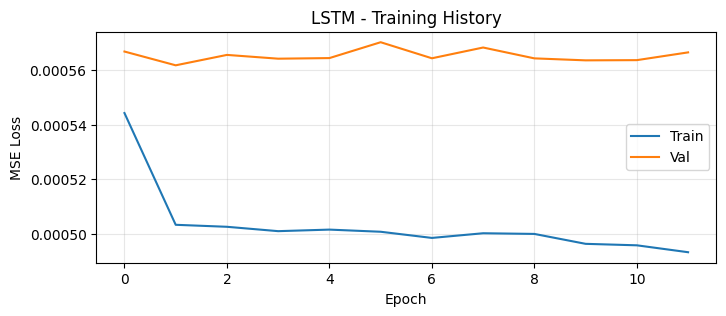


Validation:
  LSTM Val | RMSE: 0.023450 | MAE: 0.015822 | Dir Acc: 53.9% | Corr: 0.0240
Test (TSLA):
  LSTM Test | RMSE: 0.038943 | MAE: 0.028387 | Dir Acc: 49.6% | Corr: -0.0314


In [ ]:
# ==============================================================
# Train LSTM
# ==============================================================
print("=" * 60)
print("TRAINING: LSTM on log-returns + technical indicators")
print("=" * 60)
lstm_model = LSTMModel(NUM_FEATURES)
lstm_model, lstm_history = train_model(lstm_model, train_loader, val_loader, EPOCHS, LEARNING_RATE, 'LSTM')
plot_training_history(lstm_history, 'LSTM')

print("\nValidation:")
lstm_val_preds, lstm_val_targets, lstm_val_metrics = evaluate_dl_model(lstm_model, val_loader, 'LSTM Val')
print("Test (TSLA):")
lstm_test_preds, lstm_test_targets, lstm_test_metrics = evaluate_dl_model(lstm_model, test_loader, 'LSTM Test')

ALL_RESULTS['LSTM'] = {'val': lstm_val_metrics, 'test': lstm_test_metrics, 'test_preds': lstm_test_preds}

TRAINING: GRU on log-returns + technical indicators
  Epoch   1/50 | Train: 0.000593 | Val: 0.000565
  Epoch  10/50 | Train: 0.000502 | Val: 0.000565
  Early stopping at epoch 14


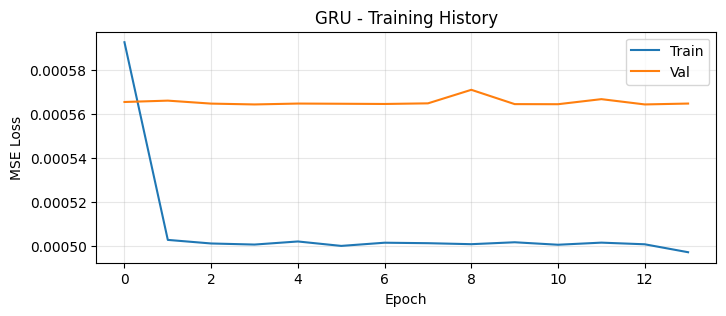


Validation:
  GRU Val | RMSE: 0.023409 | MAE: 0.015793 | Dir Acc: 54.3% | Corr: 0.0109
Test (TSLA):
  GRU Test | RMSE: 0.038880 | MAE: 0.028346 | Dir Acc: 50.2% | Corr: 0.0188


In [ ]:
# ==============================================================
# Train GRU
# ==============================================================
print("=" * 60)
print("TRAINING: GRU on log-returns + technical indicators")
print("=" * 60)
gru_model = GRUModel(NUM_FEATURES)
gru_model, gru_history = train_model(gru_model, train_loader, val_loader, EPOCHS, LEARNING_RATE, 'GRU')
plot_training_history(gru_history, 'GRU')

print("\nValidation:")
gru_val_preds, gru_val_targets, gru_val_metrics = evaluate_dl_model(gru_model, val_loader, 'GRU Val')
print("Test (TSLA):")
gru_test_preds, gru_test_targets, gru_test_metrics = evaluate_dl_model(gru_model, test_loader, 'GRU Test')

ALL_RESULTS['GRU'] = {'val': gru_val_metrics, 'test': gru_test_metrics, 'test_preds': gru_test_preds}

TRAINING: Transformer on log-returns + technical indicators
  Epoch   1/50 | Train: 0.051952 | Val: 0.000599
  Epoch  10/50 | Train: 0.000500 | Val: 0.000564
  Early stopping at epoch 13


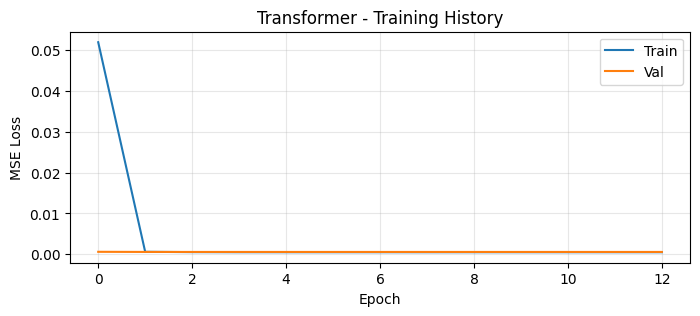


Validation:
  TF Val | RMSE: 0.023417 | MAE: 0.015825 | Dir Acc: 54.3% | Corr: 0.0000
Test (TSLA):
  TF Test | RMSE: 0.038869 | MAE: 0.028293 | Dir Acc: 50.2% | Corr: 0.0000


In [ ]:
# ==============================================================
# Train Transformer
# ==============================================================
print("=" * 60)
print("TRAINING: Transformer on log-returns + technical indicators")
print("=" * 60)
transformer_model = TransformerModel(NUM_FEATURES, seq_len=SEQUENCE_LENGTH)
transformer_model, tf_history = train_model(
    transformer_model, train_loader, val_loader, EPOCHS, LEARNING_RATE * 0.5, 'Transformer'
)
plot_training_history(tf_history, 'Transformer')

print("\nValidation:")
tf_val_preds, tf_val_targets, tf_val_metrics = evaluate_dl_model(transformer_model, val_loader, 'TF Val')
print("Test (TSLA):")
tf_test_preds, tf_test_targets, tf_test_metrics = evaluate_dl_model(transformer_model, test_loader, 'TF Test')

ALL_RESULTS['Transformer'] = {'val': tf_val_metrics, 'test': tf_test_metrics, 'test_preds': tf_test_preds}

---
## §8. Direction Classification Baselines

Beyond predicting the magnitude of returns, a key question is: **can we predict whether the stock goes up or down?** This is arguably more practically useful than return magnitude, and it maps directly to the "directional movement prediction" task in our proposal.

We compare:
- **Always predict "Up"**: Since stocks tend to go up over time, this is a surprisingly strong baseline.
- **Logistic Regression** on technical indicators
- **Random Forest** on technical indicators (captures non-linear interactions)

We also test statistical significance using a **binomial test**: is our accuracy significantly better than 50% (pure coin flip)?

In [ ]:
print("=" * 60)
print("DIRECTION CLASSIFICATION BASELINES")
print("=" * 60)

test_y_dir = classical_test_y_dir.values
n_test = len(test_y_dir)
up_ratio_test = test_y_dir.mean()
print(f"Test set ({HOLDOUT_STOCK}): {n_test} samples, {up_ratio_test*100:.1f}% up days")
print()

# Store direction results separately
DIR_RESULTS = {}

# --- Always predict UP ---
always_up_preds = np.ones(n_test)
always_up_acc = accuracy_score(test_y_dir, always_up_preds) * 100
always_up_f1 = f1_score(test_y_dir, always_up_preds, average='macro') * 100
print(f"Always Up:          Acc={always_up_acc:.1f}%, F1={always_up_f1:.1f}%")
DIR_RESULTS['Always Up'] = {'acc': always_up_acc, 'f1': always_up_f1}

# --- Logistic Regression ---
logreg = LogisticRegression(max_iter=1000, C=1.0)
logreg.fit(classical_train_X_scaled, classical_train_y_dir)
logreg_preds = logreg.predict(classical_test_X_scaled)
logreg_acc = accuracy_score(test_y_dir, logreg_preds) * 100
logreg_f1 = f1_score(test_y_dir, logreg_preds, average='macro') * 100
print(f"Logistic Regression: Acc={logreg_acc:.1f}%, F1={logreg_f1:.1f}%")
DIR_RESULTS['Logistic Reg.'] = {'acc': logreg_acc, 'f1': logreg_f1}

# --- Random Forest ---
rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(classical_train_X_scaled, classical_train_y_dir)
rf_preds = rf.predict(classical_test_X_scaled)
rf_acc = accuracy_score(test_y_dir, rf_preds) * 100
rf_f1 = f1_score(test_y_dir, rf_preds, average='macro') * 100
print(f"Random Forest:       Acc={rf_acc:.1f}%, F1={rf_f1:.1f}%")
DIR_RESULTS['Random Forest'] = {'acc': rf_acc, 'f1': rf_f1}

# --- DL model directional accuracy (from return predictions) ---
for name in ['LSTM', 'GRU', 'Transformer']:
    if name in ALL_RESULTS:
        dl_dir_acc = ALL_RESULTS[name]['test']['dir_acc']
        DIR_RESULTS[f'{name} (from returns)'] = {'acc': dl_dir_acc, 'f1': None}
        print(f"{name} (from returns): Acc={dl_dir_acc:.1f}%")

print("\n--- Random Forest Feature Importance (Top 10) ---")
importances = rf.feature_importances_
top_idx = importances.argsort()[-10:][::-1]
for idx in top_idx:
    print(f"  {FEATURE_COLS[idx]:>20s}: {importances[idx]:.4f}")

DIRECTION CLASSIFICATION BASELINES
Test set (TSLA): 530 samples, 50.2% up days

Always Up:          Acc=50.2%, F1=33.4%
Logistic Regression: Acc=50.0%, F1=47.3%
Random Forest:       Acc=47.5%, F1=45.3%
LSTM (from returns): Acc=49.6%
GRU (from returns): Acc=50.2%
Transformer (from returns): Acc=50.2%

--- Random Forest Feature Importance (Top 10) ---
          return_lag_2: 0.0647
       volume_ma_ratio: 0.0646
         volume_change: 0.0599
          return_lag_1: 0.0582
               obv_roc: 0.0574
                   rsi: 0.0573
          return_lag_5: 0.0562
       open_close_diff: 0.0562
              bb_pct_b: 0.0558
          return_lag_3: 0.0558


---
## §9. Volatility Forecasting — GARCH Baseline

Our proposal identifies volatility forecasting as a key task, and notes that it is susceptible to **concept shift** (e.g., Elon Musk tweets abruptly altering volatility dynamics). The standard baseline for volatility forecasting is the **GARCH(1,1) model** — if our deep learning models can't beat GARCH on volatility, they aren't adding value.

GARCH models the conditional variance of returns as a function of past squared residuals and past conditional variances.

GARCH(1,1) VOLATILITY BASELINE
Fitting GARCH(1,1) on TSLA training returns (2902 obs)...
                                  Mean Model                                  
                  coef    std err          t      P>|t|       95.0% Conf. Int.
------------------------------------------------------------------------------
Const           0.1212  5.896e-02      2.055  3.985e-02    [5.620e-03,  0.237]
y[1]       -6.6464e-04  2.053e-02 -3.238e-02      0.974 [-4.090e-02,3.957e-02]

Generating 530 one-step-ahead volatility forecasts...
  50/530 forecasts done...
  100/530 forecasts done...
  150/530 forecasts done...
  200/530 forecasts done...
  250/530 forecasts done...
  300/530 forecasts done...
  350/530 forecasts done...
  400/530 forecasts done...
  450/530 forecasts done...
  500/530 forecasts done...

GARCH(1,1) Volatility Forecast Results (TSLA):
  RMSE: 0.0964 | MAE: 0.0782 | Corr: 0.9105


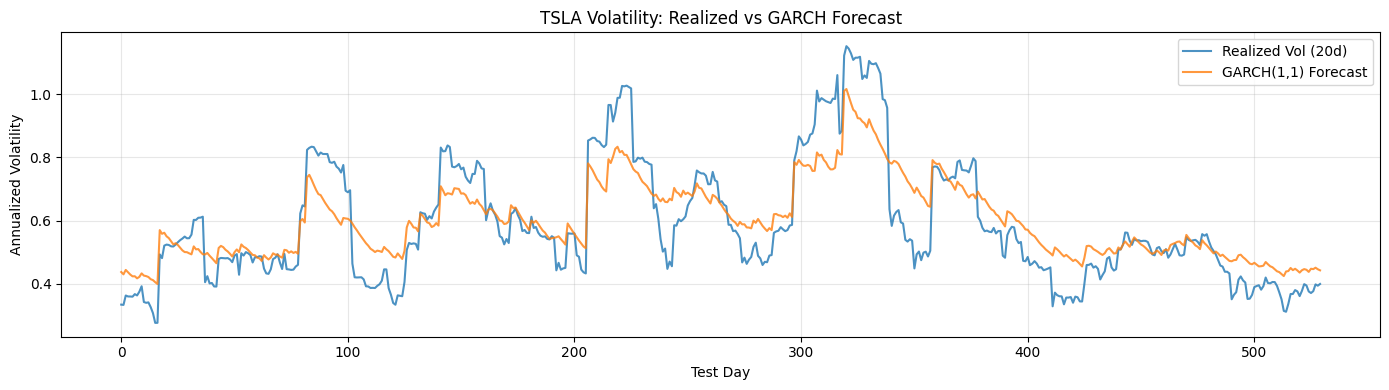

In [ ]:
print("=" * 60)
print("GARCH(1,1) VOLATILITY BASELINE")
print("=" * 60)

# Use the holdout stock's return series
holdout_returns_train = stock_splits[HOLDOUT_STOCK]['train']['log_return'].values * 100  # GARCH expects %
holdout_returns_test = stock_splits[HOLDOUT_STOCK]['test']['log_return'].values * 100

# Actual realized volatility on test (20-day rolling, annualized)
actual_vol_test = stock_splits[HOLDOUT_STOCK]['test']['realized_vol_20d'].values

print(f"Fitting GARCH(1,1) on {HOLDOUT_STOCK} training returns ({len(holdout_returns_train)} obs)...")

try:
    # Fit GARCH(1,1)
    garch = arch_model(holdout_returns_train, vol='Garch', p=1, q=1, mean='AR', lags=1)
    garch_fit = garch.fit(disp='off')
    print(garch_fit.summary().tables[1])

    # Forecast conditional volatility one step ahead, rolling
    garch_vol_preds = []
    all_returns = list(holdout_returns_train)

    print(f"\nGenerating {len(holdout_returns_test)} one-step-ahead volatility forecasts...")
    for i in range(len(holdout_returns_test)):
        am = arch_model(np.array(all_returns), vol='Garch', p=1, q=1, mean='AR', lags=1)
        res = am.fit(disp='off', show_warning=False)
        forecast = res.forecast(horizon=1)
        # Conditional variance -> annualized vol
        cond_var = forecast.variance.values[-1, 0]
        daily_vol = np.sqrt(cond_var) / 100  # Back to decimal from %
        annual_vol = daily_vol * np.sqrt(252)
        garch_vol_preds.append(annual_vol)
        all_returns.append(holdout_returns_test[i])

        if (i + 1) % 50 == 0:
            print(f"  {i+1}/{len(holdout_returns_test)} forecasts done...")

    garch_vol_preds = np.array(garch_vol_preds)

    # Evaluate GARCH vs actual realized vol
    vol_mse = np.mean((actual_vol_test - garch_vol_preds) ** 2)
    vol_rmse = np.sqrt(vol_mse)
    vol_mae = np.mean(np.abs(actual_vol_test - garch_vol_preds))
    vol_corr = np.corrcoef(actual_vol_test, garch_vol_preds)[0, 1] if np.std(garch_vol_preds) > 0 else 0

    print(f"\nGARCH(1,1) Volatility Forecast Results ({HOLDOUT_STOCK}):")
    print(f"  RMSE: {vol_rmse:.4f} | MAE: {vol_mae:.4f} | Corr: {vol_corr:.4f}")

    # Plot
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(actual_vol_test, label='Realized Vol (20d)', alpha=0.8)
    ax.plot(garch_vol_preds, label='GARCH(1,1) Forecast', alpha=0.8)
    ax.set_title(f'{HOLDOUT_STOCK} Volatility: Realized vs GARCH Forecast')
    ax.set_ylabel('Annualized Volatility')
    ax.set_xlabel('Test Day')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    GARCH_RESULTS = {'rmse': vol_rmse, 'mae': vol_mae, 'corr': vol_corr}

except Exception as e:
    print(f"GARCH failed: {e}")
    GARCH_RESULTS = None

---
## §10. Statistical Significance Tests

Raw performance numbers mean nothing without significance testing. We apply two tests:

1. **Binomial Test** for directional accuracy: Is a model's accuracy significantly different from 50% (random guessing)? With ~250 test samples, even 55% accuracy might not be significant.

2. **Diebold-Mariano Test** for forecast comparison: Given two sets of forecasts, are their errors significantly different? This tells us whether one model is statistically better than another, not just numerically.

In [ ]:
print("=" * 60)
print("STATISTICAL SIGNIFICANCE TESTS")
print("=" * 60)

# ==============================================================
# 10a. Binomial Test for Directional Accuracy
# ==============================================================
print("\n--- Binomial Test: Is directional accuracy > 50%? ---")
print(f"(Test set: {n_test} samples, null hypothesis: p = 0.5)\n")

for name, res in DIR_RESULTS.items():
    acc = res['acc'] / 100
    n_correct = int(round(acc * n_test))
    # One-sided binomial test: is accuracy significantly > 0.5?
    binom_p = stats.binomtest(n_correct, n_test, 0.5, alternative='greater').pvalue
    sig = '***' if binom_p < 0.001 else '**' if binom_p < 0.01 else '*' if binom_p < 0.05 else 'n.s.'
    print(f"  {name:25s}: {acc*100:5.1f}% | p-value: {binom_p:.4f} {sig}")


# ==============================================================
# 10b. Diebold-Mariano Test for Forecast Comparison
# ==============================================================
print("\n--- Diebold-Mariano Test: Model vs Naive Baseline ---")
print("(H0: equal predictive accuracy, two-sided)\n")

def diebold_mariano_test(actual, pred1, pred2, h=1):
    """
    Diebold-Mariano test for comparing two forecasts.
    Tests H0: E[d_t] = 0 where d_t = e1_t^2 - e2_t^2
    Returns test statistic and p-value.
    """
    e1 = actual - pred1
    e2 = actual - pred2
    d = e1**2 - e2**2  # Loss differential
    n = len(d)
    d_mean = np.mean(d)
    d_var = np.var(d, ddof=1)

    # Harvey, Leybourne and Newbold (1997) correction
    if d_var > 0:
        dm_stat = d_mean / np.sqrt(d_var / n)
        p_value = 2 * (1 - stats.norm.cdf(abs(dm_stat)))
    else:
        dm_stat = 0.0
        p_value = 1.0

    return dm_stat, p_value


# Get aligned test targets for DL models
# Note: DL models have slightly fewer predictions due to windowing
naive_for_dm = classical_test_y_return.values
naive_preds_for_dm = np.zeros(len(naive_for_dm))

# Compare each model against naive
for name, res in ALL_RESULTS.items():
    if name == 'Naive (r=0)' or res.get('test_preds') is None:
        continue

    preds = res['test_preds']
    # Align lengths (DL models may have fewer predictions)
    min_len = min(len(preds), len(naive_for_dm))
    actual = naive_for_dm[:min_len]
    p1 = naive_preds_for_dm[:min_len]
    p2 = preds[:min_len]

    dm_stat, dm_p = diebold_mariano_test(actual, p1, p2)
    sig = '***' if dm_p < 0.001 else '**' if dm_p < 0.01 else '*' if dm_p < 0.05 else 'n.s.'
    direction = 'BETTER' if dm_stat > 0 else 'WORSE' if dm_stat < 0 else 'EQUAL'
    print(f"  {name:18s} vs Naive: DM={dm_stat:+.3f}, p={dm_p:.4f} {sig} ({direction})")

STATISTICAL SIGNIFICANCE TESTS

--- Binomial Test: Is directional accuracy > 50%? ---
(Test set: 530 samples, null hypothesis: p = 0.5)

  Always Up                :  50.2% | p-value: 0.4827 n.s.
  Logistic Reg.            :  50.0% | p-value: 0.5173 n.s.
  Random Forest            :  47.5% | p-value: 0.8796 n.s.
  LSTM (from returns)      :  49.6% | p-value: 0.5860 n.s.
  GRU (from returns)       :  50.2% | p-value: 0.4827 n.s.
  Transformer (from returns):  50.2% | p-value: 0.4827 n.s.

--- Diebold-Mariano Test: Model vs Naive Baseline ---
(H0: equal predictive accuracy, two-sided)

  Hist. Mean         vs Naive: DM=+0.295, p=0.7677 n.s. (BETTER)
  EMA (span=10)      vs Naive: DM=-3.073, p=0.0021 ** (WORSE)
  Linear Reg.        vs Naive: DM=+0.151, p=0.8797 n.s. (BETTER)
  Ridge Reg.         vs Naive: DM=+0.152, p=0.8795 n.s. (BETTER)
  ARIMA(5,0,1)       vs Naive: DM=-0.545, p=0.5859 n.s. (WORSE)
  LSTM               vs Naive: DM=-0.687, p=0.4922 n.s. (WORSE)
  GRU                vs 

---
## §11. Final Comparison Dashboard

Consolidated view of all baselines across all tasks, establishing the numbers our sentiment-enhanced and multi-task models must beat.

In [ ]:
print("=" * 90)
print(f"COMPREHENSIVE BASELINE RESULTS — Test Stock: {HOLDOUT_STOCK}")
print("=" * 90)

# ==============================================================
# Task 1: Return Prediction
# ==============================================================
print("\n--- TASK 1: LOG-RETURN PREDICTION ---")
print(f"{'Model':<20} {'RMSE':>10} {'MAE':>10} {'Dir Acc':>10} {'Corr':>10}")
print("-" * 62)
for name, res in ALL_RESULTS.items():
    t = res['test']
    if t is not None:
        print(f"{name:<20} {t['rmse']:>10.6f} {t['mae']:>10.6f} {t['dir_acc']:>9.1f}% {t['corr']:>10.4f}")

# ==============================================================
# Task 2: Direction Classification
# ==============================================================
print("\n--- TASK 2: DIRECTION CLASSIFICATION ---")
print(f"{'Model':<30} {'Accuracy':>10} {'F1':>10}")
print("-" * 52)
for name, res in DIR_RESULTS.items():
    f1_str = f"{res['f1']:.1f}%" if res['f1'] is not None else 'N/A'
    print(f"{name:<30} {res['acc']:>9.1f}% {f1_str:>10}")

# ==============================================================
# Task 3: Volatility Forecasting
# ==============================================================
print("\n--- TASK 3: VOLATILITY FORECASTING ---")
if GARCH_RESULTS:
    print(f"{'Model':<20} {'RMSE':>10} {'MAE':>10} {'Corr':>10}")
    print("-" * 52)
    print(f"{'GARCH(1,1)':<20} {GARCH_RESULTS['rmse']:>10.4f} {GARCH_RESULTS['mae']:>10.4f} {GARCH_RESULTS['corr']:>10.4f}")
else:
    print("GARCH baseline was not computed.")

# ==============================================================
# Summary of baselines to beat
# ==============================================================
print("\n" + "=" * 90)
print("BASELINES TO BEAT (for sentiment-enhanced & multi-task models):")
print("=" * 90)
if ALL_RESULTS:
    best_return = min(ALL_RESULTS.items(), key=lambda x: x[1]['test']['rmse'] if x[1]['test'] else float('inf'))
    print(f"  Return prediction:  Best RMSE = {best_return[1]['test']['rmse']:.6f} ({best_return[0]})")
if DIR_RESULTS:
    best_dir = max(DIR_RESULTS.items(), key=lambda x: x[1]['acc'])
    print(f"  Direction accuracy: Best Acc  = {best_dir[1]['acc']:.1f}% ({best_dir[0]})")
if GARCH_RESULTS:
    print(f"  Volatility:         GARCH RMSE = {GARCH_RESULTS['rmse']:.4f}")

COMPREHENSIVE BASELINE RESULTS — Test Stock: TSLA

--- TASK 1: LOG-RETURN PREDICTION ---
Model                      RMSE        MAE    Dir Acc       Corr
--------------------------------------------------------------
Naive (r=0)            0.038880   0.028290      49.8%     0.0000
Hist. Mean             0.038867   0.028298      50.2%     0.0000
EMA (span=10)          0.040887   0.029846      49.6%    -0.0196
Linear Reg.            0.038850   0.028322      49.8%     0.0471
Ridge Reg.             0.038850   0.028322      49.8%     0.0471
ARIMA(5,0,1)           0.038929   0.028355      47.0%    -0.0324
LSTM                   0.038943   0.028387      49.6%    -0.0314
GRU                    0.038880   0.028346      50.2%     0.0188
Transformer            0.038869   0.028293      50.2%     0.0000

--- TASK 2: DIRECTION CLASSIFICATION ---
Model                            Accuracy         F1
----------------------------------------------------
Always Up                           50.2%      33.

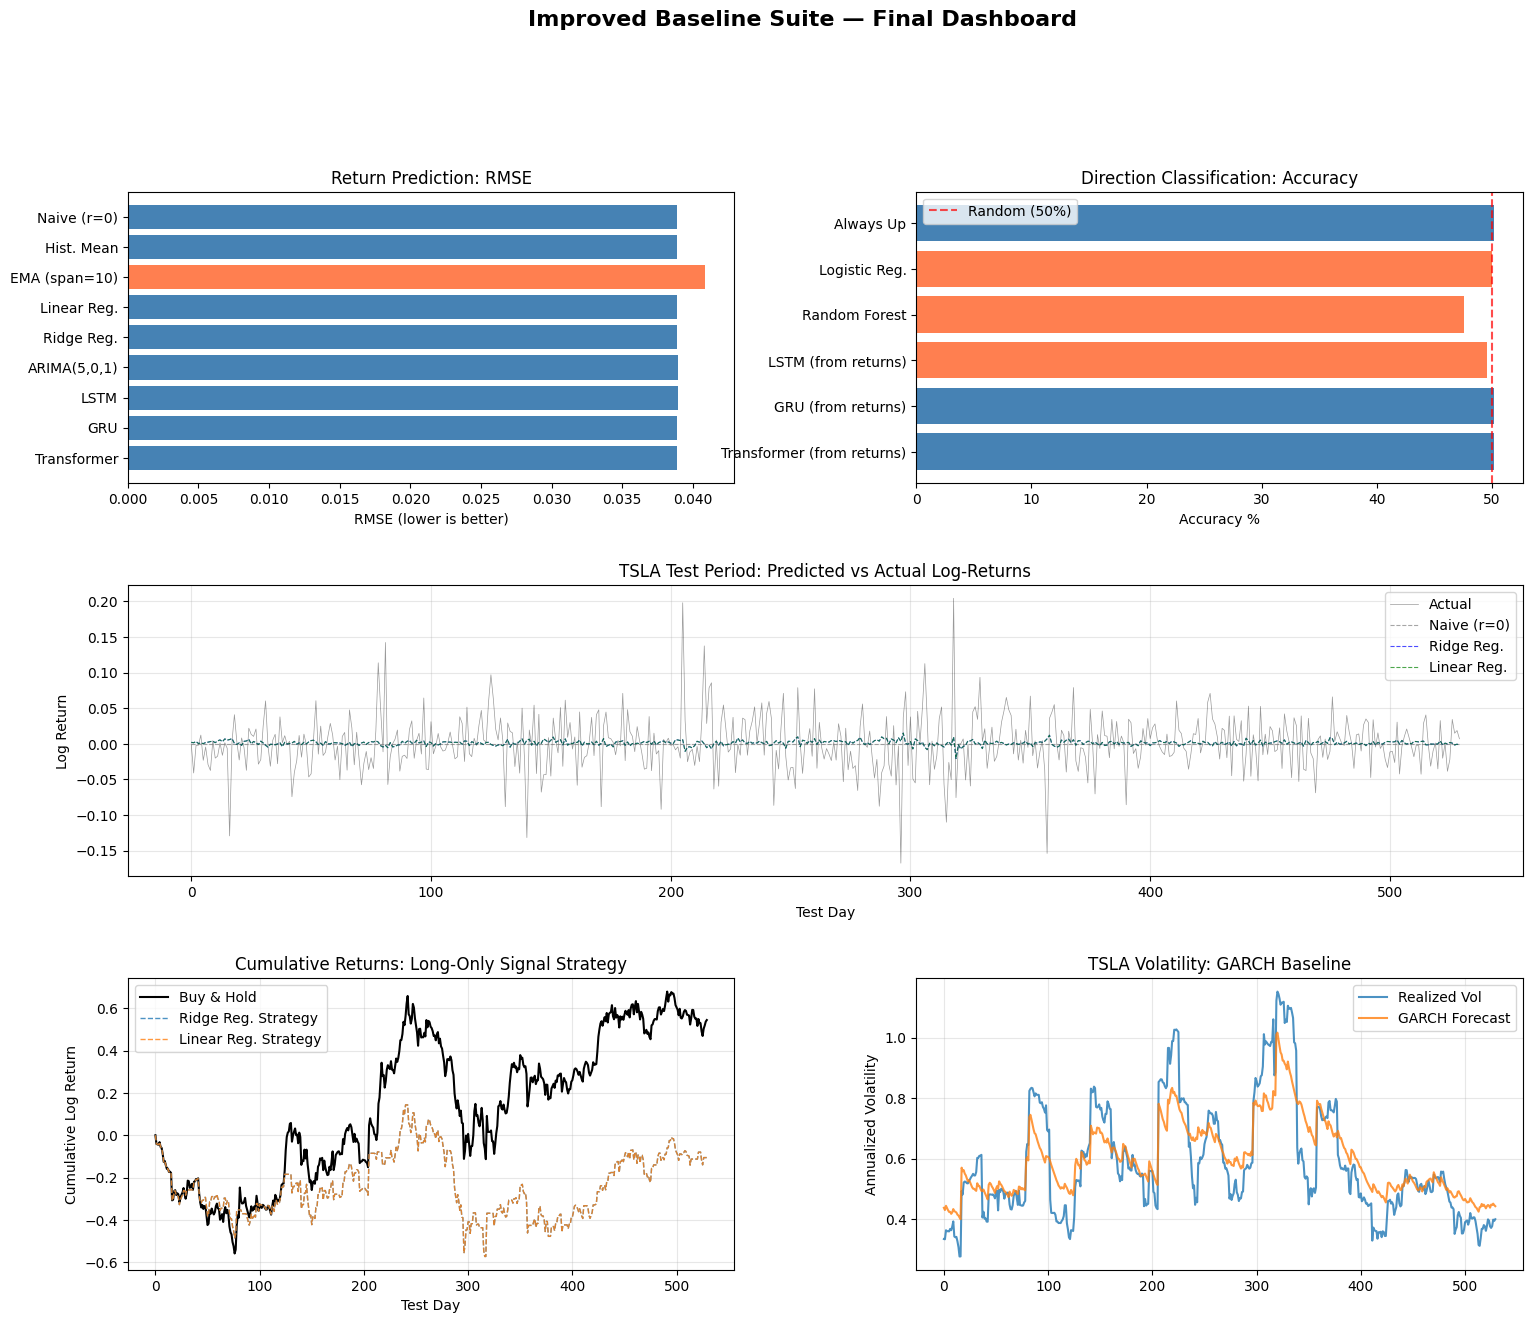

In [ ]:
# ==============================================================
# Visualization: Final Comparison Plots
# ==============================================================

fig = plt.figure(figsize=(18, 14))
gs = gridspec.GridSpec(3, 2, hspace=0.35, wspace=0.3)

# --- Plot 1: Return RMSE comparison ---
ax1 = fig.add_subplot(gs[0, 0])
names = [n for n, r in ALL_RESULTS.items() if r['test'] is not None]
rmses = [ALL_RESULTS[n]['test']['rmse'] for n in names]
colors = ['coral' if r > min(rmses) * 1.01 else 'steelblue' for r in rmses]
ax1.barh(names, rmses, color=colors)
ax1.set_xlabel('RMSE (lower is better)')
ax1.set_title('Return Prediction: RMSE')
ax1.invert_yaxis()

# --- Plot 2: Directional accuracy comparison ---
ax2 = fig.add_subplot(gs[0, 1])
dir_names = list(DIR_RESULTS.keys())
dir_accs = [DIR_RESULTS[n]['acc'] for n in dir_names]
colors2 = ['steelblue' if a > 50 else 'coral' for a in dir_accs]
ax2.barh(dir_names, dir_accs, color=colors2)
ax2.axvline(50, color='r', linestyle='--', alpha=0.7, label='Random (50%)')
ax2.set_xlabel('Accuracy %')
ax2.set_title('Direction Classification: Accuracy')
ax2.legend()
ax2.invert_yaxis()

# --- Plot 3: Predicted vs Actual Returns (best model) ---
ax3 = fig.add_subplot(gs[1, :])
test_actuals = classical_test_y_return.values
ax3.plot(test_actuals, 'k-', alpha=0.4, linewidth=0.5, label='Actual')
# Overlay a few key models
for name, color in [('Naive (r=0)', 'gray'), ('Ridge Reg.', 'blue'), ('Linear Reg.', 'green')]:
    if name in ALL_RESULTS and ALL_RESULTS[name]['test_preds'] is not None:
        preds = ALL_RESULTS[name]['test_preds'][:len(test_actuals)]
        ax3.plot(preds, '--', alpha=0.7, linewidth=0.8, label=name, color=color)
ax3.set_title(f'{HOLDOUT_STOCK} Test Period: Predicted vs Actual Log-Returns')
ax3.set_ylabel('Log Return')
ax3.set_xlabel('Test Day')
ax3.legend(loc='upper right')
ax3.grid(True, alpha=0.3)

# --- Plot 4: Cumulative return comparison ---
ax4 = fig.add_subplot(gs[2, 0])
# Simple trading strategy: go long if predicted return > 0, else flat
cum_actual = np.cumsum(test_actuals)
ax4.plot(cum_actual, 'k-', linewidth=1.5, label='Buy & Hold')
for name in ['Ridge Reg.', 'Linear Reg.']:
    if name in ALL_RESULTS and ALL_RESULTS[name]['test_preds'] is not None:
        preds = ALL_RESULTS[name]['test_preds'][:len(test_actuals)]
        signal = (preds > 0).astype(float)
        strategy_returns = test_actuals * signal
        cum_strategy = np.cumsum(strategy_returns)
        ax4.plot(cum_strategy, '--', linewidth=1, alpha=0.8, label=f'{name} Strategy')
ax4.set_title('Cumulative Returns: Long-Only Signal Strategy')
ax4.set_ylabel('Cumulative Log Return')
ax4.set_xlabel('Test Day')
ax4.legend()
ax4.grid(True, alpha=0.3)

# --- Plot 5: Volatility forecast (if available) ---
ax5 = fig.add_subplot(gs[2, 1])
if GARCH_RESULTS:
    ax5.plot(actual_vol_test, label='Realized Vol', alpha=0.8)
    ax5.plot(garch_vol_preds, label='GARCH Forecast', alpha=0.8)
    ax5.set_title(f'{HOLDOUT_STOCK} Volatility: GARCH Baseline')
    ax5.set_ylabel('Annualized Volatility')
    ax5.legend()
else:
    ax5.text(0.5, 0.5, 'GARCH not computed', ha='center', va='center', fontsize=14)
    ax5.set_title('Volatility Forecast')
ax5.grid(True, alpha=0.3)

plt.suptitle('Improved Baseline Suite — Final Dashboard', fontsize=16, fontweight='bold', y=1.01)
plt.show()

---
## §12. Key Takeaways & Next Steps

### What this notebook establishes:

1. **Return prediction baselines** across naive, statistical, and deep learning approaches — all evaluated on the same holdout stock with the same train/test split.

2. **Direction classification baselines** showing whether any model can predict up/down better than chance, with binomial tests for significance.

3. **Volatility forecasting baseline** via GARCH(1,1) — the standard bar for our multi-task volatility head.

4. **Statistical significance tests** (Diebold-Mariano, binomial) so we can make honest claims about model improvements.

### Baselines to beat (for sentiment-enhanced models):
- **Return RMSE**: The best model's RMSE from this notebook
- **Directional accuracy**: The best classifier's accuracy from this notebook (must be significantly > 50%)
- **Volatility RMSE**: GARCH(1,1) RMSE from this notebook

### Next steps:
1. **Integrate daily sentiment signals** from our GDELT/Kaggle news pipeline as additional input features
2. **Build the multi-task model** with shared backbone + task-specific heads (as proposed)
3. **Compare against these baselines** using the same evaluation protocol and significance tests
4. **Analyze domain shift**: Compare baseline degradation across different market regimes